Download the dataset folder

In [ ]:
# set the environment variables BEFORE importing the kaggle module.
import os
os.environ['KAGGLE_USERNAME'] = 'your_kaggle_username'  # replace with your Kaggle username
os.environ['KAGGLE_KEY'] = 'your_kaggle_key'  # replace with your Kaggle API key
import kaggle

kaggle.api.authenticate()

kaggle.api.dataset_download_files('mondejar/mitbih-database',path='./ECG',unzip=True)

Dataset URL: https://www.kaggle.com/datasets/mondejar/mitbih-database


Checking For GPU availability

In [1]:
!python3 -c "import tensorflow as tf; print(tf.config.list_physical_devices('GPU'))"

2026-02-23 06:45:40.051391: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras import layers
import wfdb # For loading ECG data
from scipy.signal import butter, filtfilt # For siignal preprocessing
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight # For handling class imbalance
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

2026-02-23 06:55:58.543646: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
import mlflow
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("ECG_Anomaly_Detection")
print(mlflow.get_tracking_uri())

# Enable autologging
from mlflow.tensorflow import autolog
# Disable autologging to avoid the Dataset bug
autolog(
    log_models=True,
    log_input_examples=True,
    log_model_signatures=True,
    log_every_n_steps=1,
    disable=True
)

2026/02/23 08:58:25 INFO mlflow.tracking.fluent: Experiment with name 'ECG_Anomaly_Detection' does not exist. Creating a new experiment.


http://127.0.0.1:5000


In [10]:
# Set device (GPU if available)
import tensorflow as tf
gpus=tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus=tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus),"Physical GPUs,", len(logical_gpus), "Logical GPUs")
        
    except RuntimeError as e:
        print(e)
else:
    print("Using CPU")

1 Physical GPUs, 1 Logical GPUs


I0000 00:00:1771832701.448481   16039 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3618 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [20]:
# Step 1: Data Preprocessing
def load_ecg_data(record_ids=['101', '106', '108', '109', '112', '114', '116', '117', '118', '119', '122', '123', '124','201', '203', '205', '207', '208'],sampling_rate=360, window_size=360*5):
    """
    Loads ECG signals, filters noise, segments into windows, and labels anomalies.
    - Normal beats (N): label 0
    - Anomalies (V, S, etc.): label 1
    """
    all_signals=[]
    all_labels=[]
    signal=None
    for record_id in record_ids:
        # 1. Load the ECG signal (the actual waveform)
        # pn_dir is for PhysioNet database directories, not local files
        # wfdb.rdrecord : Read a WFDB record and return the signal and record descriptors as attributes in a Record or MultiRecord object.
        record = wfdb.rdrecord(f'mitdb/{record_id}', pn_dir='mitdb') # Assumes MIT-BIH in 'mitdb/' folder
        signal=record.p_signal[:,0]
        # 2. Load the annotations (event markers)
        annotation=wfdb.rdann(f'{record_id}','atr',pn_dir='mitdb')

        # Band-pass filter to remove noise (Butterworth, 0.5-40 Hz)
        b, a =butter(4, [0.5/sampling_rate*2, 40/sampling_rate*2], btype='band')
        signal_filtered=filtfilt(b, a, signal)

        # Normalize
        scaler=MinMaxScaler()
        signal_normalized=scaler.fit_transform(signal_filtered.reshape(-1,1)).flatten()
        """Window Size (5 seconds):
        Too short (1s): Can't see complete heartbeats
        Too long (30s): Too much data, hard for model to learn patterns
        Just right (5s): Captures 5-8 heartbeats, good for rhythm analysis
        
        Overlap (50%):
        No overlap: Might miss patterns at window boundaries
        50% overlap: Ensures every heartbeat is fully captured in some window
        Creates more training examples from same data""" 
        for i in range(0, len(signal_normalized)-window_size, int(window_size/2)):
            window = signal_normalized[i:i+window_size]
            if len(window) == window_size:
                all_signals.append(window)
                
                # Label based on annotations in window (simple: if any anomaly symbol, label 1)
                window_start = i / sampling_rate
                window_end = (i + window_size) / sampling_rate
                ann_symbols = [annotation.symbol[j] for j in range(len(annotation.sample))
                               if window_start <= annotation.sample[j]/sampling_rate <= window_end]
                label = 1 if any(sym in ['V', 'S', 'F', 'A', 'E', 'J', 'P', '/'] for sym in ann_symbols) else 0
                all_labels.append(label)
            

    return np.array(all_signals), np.array(all_labels), scaler



In [21]:
# Step 2: Model Definition
def model_build(input_shape=(1800,), hidden_size=256, num_layers=2, dropout=0.2):
    """
    Corrected Bidirectional LSTM for ECG anomaly detection.
    """
    model = keras.Sequential()
    
    # Reshape input - consider using more features if available
    model.add(layers.Reshape((input_shape[0], 1), input_shape=input_shape))
    
    # Stack multiple LSTM layers properly
    for i in range(num_layers):
        return_sequences = (i < num_layers - 1)  # True for all but last layer
        
        if i == 0:
            # First layer
            model.add(layers.Bidirectional(
                layers.LSTM(hidden_size,
                           return_sequences=return_sequences,
                           dropout=dropout),
                input_shape=(input_shape[0], 1)
            ))
        else:
            # Subsequent layers
            model.add(layers.Bidirectional(
                layers.LSTM(hidden_size,
                           return_sequences=return_sequences,
                           dropout=dropout)
            ))
    
    # Dense classifier
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(dropout))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(dropout))
    
    # Output layer for binary classification
    model.add(layers.Dense(1, activation='sigmoid'))

    # Compile the model 
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                 loss='binary_crossentropy',
                 metrics=['accuracy', 'precision', 'recall'])  # Added metrics for imbalance

    return model

In [22]:
# Step 3: Training Function (Using model.fit with validation)
def train_model(model,X_train,y_train, X_val, y_val, num_epochs=20, batch_size=32):
    # Convert to tf.data.Dataset for efficient batching
    # Now: (ECG1,0), (ECG2,1), (ECG3,0), ..., (ECG1000,1) - by tensor_slices
    # Now: (ECG45,1), (ECG12,0), (ECG78,1), ..., (ECG3,0)  # Random order by shuffle
    # Now: 
    # Batch1: ([ECG45, ECG12, ..., ECG88], [1, 0, ..., 1])  # 32 samples - batch 
    train_dataset=tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(10000).batch(32)
    val_dataset=tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(32)
    
    # Compute class weights to handle imbalance
    class_weights=compute_class_weight("balanced", classes=np.unique(y_train), y=y_train.flatten(),sample_weight=None)
    class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
    print(f"Class weights: {class_weight_dict}")  # e.g., {0: 0.55, 1: 5.45}
    
    # Custom callback for F1 tracking (Keras doesn't have built-in F1, so manual)
    class F1CallBack(keras.callbacks.Callback):
        def __init__(self, val_dataset):
            super().__init__()
            self.val_dataset=val_dataset
            self.train_f1,self.val_f1=[], []
        def on_epoch_end(self, epoch, logs=None):
            # Train F1
            train_preds=(model.predict(X_train[:len(y_train)//batch_size*batch_size])>0.5).astype(int).flatten()
            trainf1=f1_score(y_train[:len(train_preds)], train_preds)
            self.train_f1.append(trainf1)

            #Val F1
            val_preds=(model.predict(X_val)>0.5).astype(int).flatten()
            valf1=f1_score(y_val, val_preds)
            self.val_f1.append(valf1)   

            print(f' - Train F1: {trainf1:.4f}, Val F1: {valf1:.4f}')


    # Create an MLflow run and add the callback
    with mlflow.start_run(run_name="ECG_LSTM_Training") as run:
        # Log hyperparameters
        mlflow.log_param("num_epochs", num_epochs)
        mlflow.log_param("batch_size", batch_size)
        mlflow.log_param("hidden_size", 256)
        mlflow.log_param("num_layers", 2)
        mlflow.log_param("dropout", 0.2)
        class ManualMlFlowCallback(keras.callbacks.Callback):
            def on_epoch_end(self, epoch, logs=None):
                 if logs :
                     for metric_name, metric_value in logs.items():
                         mlflow.log_metric(metric_name, metric_value, step=epoch)
        history=model.fit(
            train_dataset,
            epochs=num_epochs,
            validation_data=val_dataset,
            # callbacks=[F1CallBack(val_dataset)],
            callbacks=[ManualMlFlowCallback()],  # Log F1 scores manually
            class_weight=class_weight_dict,  # Pass class weights for imbalance
            verbose=1
        )
    
    return history.history['loss'], history.history['val_loss'], [], []  # F1s in callback


In [30]:
import seaborn as sns
import mlflow 
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,

)
# Step 4: Evaluation and Visualization (Adapted for TF)
def evaluate_and_visualize(model, X_test, y_test, experiment_name="ECG_Anomaly_Detection", run_name="ECG_LSTM_Evaluation"):
    import mlflow 
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment(experiment_name)
    # Predictions and Metrics
    y_pred_prob=model.predict(X_test)
    y_pred = (y_pred_prob >0.5).astype(int).flatten()
    y_test_flat = y_test.flatten()
    
    # Clculate metrics and log to MLflow
    metrics = {
        "accuracy": accuracy_score(y_test_flat, y_pred),
        "precision": precision_score(y_test_flat, y_pred),
        "recall": recall_score(y_test_flat, y_pred),
        "f1_score": f1_score(y_test_flat, y_pred),
        "roc_auc": roc_auc_score(y_test_flat, y_pred_prob.flatten())
    }
    # Start an MLflow run to log metrics
    with mlflow.start_run(run_name=run_name):
        # 1. Log parameters (model configuration)
        mlflow.log_params({
            "test_samples": len(X_test),
            "threshold": 0.5,
            "model_type": model.__class__.__name__
        })
        # 2. Log metrics
        mlflow.log_metrics(metrics)  # Log all metrics at once
         # 3. Log classification report as JSON artifact
        report = classification_report(y_test_flat, y_pred, output_dict=True)
        mlflow.log_dict(report, "classification_report.json")
        # 4. Generate and log confusion matrix
        cm = confusion_matrix(y_test_flat, y_pred)
        fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm)
        ax_cm.set_title('Confusion Matrix')
        ax_cm.set_xlabel('Predicted')
        ax_cm.set_ylabel('Actual')
        mlflow.log_figure(fig_cm, "confusion_matrix.png")
        plt.close(fig_cm)
        # 5. Generate and log ROC curve
        fpr, tpr, _ = roc_curve(y_test_flat, y_pred_prob.flatten())
        fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
        ax_roc.plot(fpr, tpr, label=f'ROC Curve (AUC = {metrics["roc_auc"]:.3f})')
        ax_roc.plot([0, 1], [0, 1], 'k--', label='Random')
        ax_roc.set_xlabel('False Positive Rate')
        ax_roc.set_ylabel('True Positive Rate')
        ax_roc.set_title('ROC Curve')
        ax_roc.legend()
        mlflow.log_figure(fig_roc, "roc_curve.png")
        plt.close(fig_roc)
        # 6. Generate and log Precision-Recall curve
        precision_vals, recall_vals, _ = precision_recall_curve(y_test_flat, y_pred_prob.flatten())
        fig_pr, ax_pr = plt.subplots(figsize=(8, 6))
        ax_pr.plot(recall_vals, precision_vals, label='Precision-Recall Curve')
        ax_pr.set_xlabel('Recall')
        ax_pr.set_ylabel('Precision')
        ax_pr.set_title('Precision-Recall Curve')
        ax_pr.legend()
        mlflow.log_figure(fig_pr, "precision_recall_curve.png")
        plt.close(fig_pr)
         # 7. Log prediction distribution plot
        fig_dist, ax_dist = plt.subplots(figsize=(8, 6))
        ax_dist.hist(y_pred_prob[y_test_flat == 0], bins=50, alpha=0.5, label='Normal (0)', density=True)
        ax_dist.hist(y_pred_prob[y_test_flat == 1], bins=50, alpha=0.5, label='Anomaly (1)', density=True)
        ax_dist.set_xlabel('Predicted Probability')
        ax_dist.set_ylabel('Density')
        ax_dist.set_title('Prediction Distribution')
        ax_dist.legend()
        mlflow.log_figure(fig_dist, "prediction_distribution.png")
        plt.close(fig_dist)
        
        # Predictions 
        test_preds=(model.predict(X_test)>0.5).astype(int).flatten()

        # Metrics
        f1 = f1_score(y_test_flat, test_preds)
        print("\nClassification Report:")
        print(classification_report(y_test_flat, test_preds, target_names=['Normal', 'Anomaly']))
        print(f"Overall F1-Score: {f1:.4f}")
        mlflow.log_metric("f1_score", f1)
        # 8. Log sample predictions as CSV artifact
        sample_results = pd.DataFrame({
            'actual': y_test_flat[:100],
            'predicted': y_pred[:100],
            'probability': y_pred_prob.flatten()[:100]
        })
        sample_results.to_csv("sample_predictions.csv", index=False)
        mlflow.log_artifact("sample_predictions.csv")
        
        # 9. Log model with signature and input example
        import mlflow.tensorflow
        from mlflow.models import infer_signature
        
        signature = infer_signature(X_test[:5], model.predict(X_test[:5]))
        mlflow.tensorflow.log_model(
            model, 
            "model",
            signature=signature,
            input_example=X_test[:5]
        )
        
        print(f"Evaluation complete! Run ID: {mlflow.active_run().info.run_id}")
        print(f"View results at: http://127.0.0.1:5000")
        
    return metrics

    # # Confution Matrix
    # cm=confusion_matrix(y_test,test_preds)
    # plt.figure(figsize=(6,4))
    # plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    # plt.title('Confusion Matrix')
    # plt.colorbar()
    # tick_marks = np.arange(2)
    # plt.xticks(tick_marks, ['Normal', 'Anomaly'])
    # plt.yticks(tick_marks, ['Normal', 'Anomaly'])
    # plt.ylabel('True Label')
    # plt.xlabel('Predicted Label')
    # plt.show()


    # # Plot sample prediction
    # sample_idx = 0
    # sample_signal = X_test[sample_idx:sample_idx+1]
    # pred_prob = model.predict(sample_signal)[0][0]
    # pred = pred_prob > 0.5
    # plt.figure(figsize=(12,4))
    # plt.plot(sample_signal.squeeze())
    # plt.title(f'Sample ECG Window - True: {y_test[sample_idx]}, Pred: {pred} (prob: {pred_prob:.2f})')
    # plt.xlabel('Time Steps')
    # plt.ylabel('Normalized Amplitude')
    # plt.show()

In [15]:
# Execute the all functionality 

# Load and prepare data
signals, labels, scaler=load_ecg_data()
print(f"Loaded {len(signals)} windows: {np.bincount(labels)} (normal/anomaly)")

# Check the imbalance data in the dataset
print(f"ClassDistribution : Normal(0) {np.sum(labels == 0)}, Anomaly(1) {np.sum(labels == 1)}")
print(f"Imbalanced dataset : {np.sum(labels==0)/np.sum(labels==1):.2f} (Normal:Anomaly)")

# Split data
X_train, X_temp, y_train, y_temp=train_test_split(signals, labels, test_size=0.4, random_state=44)
X_val, X_test, y_val,y_test=train_test_split(X_temp, y_temp, test_size=0.5, random_state=44)

# Reshape labels to (n_samples, 1) for binary_crossentropy           
y_train = y_train.reshape(-1, 1)                                    
y_val = y_val.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

# Input to LSTM: (32, 1800, 1) ← Perfect!
# 32 batches, 1800 timesteps, 1 ECG voltage per timestep
# Build and summarize Model
model=model_build(input_shape=(signals.shape[1],))
model.summary()


Loaded 12978 windows: [9626 3352] (normal/anomaly)
ClassDistribution : Normal(0) 9626, Anomaly(1) 3352
Imbalanced dataset : 2.87 (Normal:Anomaly)


/mnt/c/Users/Anupam/ubuntu-venv/lib/python3.12/site-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/mnt/c/Users/Anupam/ubuntu-venv/lib/python3.12/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 1800, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 1800, 512)      │       528,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 512)            │     1,574,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,177,281 (8.31 MB)

 Trainable params: 2,177,281 (8.31 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.count_params()

2177281

In [17]:
signals.shape, signals[0,901:1000], signals[1,:90]

((12978, 1800),
 array([0.49316449, 0.49332578, 0.49330196, 0.4931242 , 0.49283668,
        0.49250992, 0.49223082, 0.49207548, 0.4920842 , 0.49224766,
        0.49250142, 0.49272913, 0.49278431, 0.49253905, 0.49194847,
        0.49109621, 0.49018485, 0.48946599, 0.48914561, 0.48931474,
        0.4899326 , 0.49085093, 0.49184965, 0.49266848, 0.4930469 ,
        0.49279224, 0.49186742, 0.49045105, 0.48891429, 0.48769998,
        0.48715408, 0.48739592, 0.48829173, 0.4895343 , 0.49077413,
        0.49173147, 0.49224832, 0.49228896, 0.49192586, 0.49133008,
        0.49074225, 0.49039129, 0.49038172, 0.49063206, 0.49093247,
        0.49109439, 0.49107899, 0.49100397, 0.49103198, 0.49124085,
        0.49157945, 0.49192685, 0.49218481, 0.49232382, 0.49236599,
        0.49235158, 0.4923379 , 0.49242643, 0.49276976, 0.49352245,
        0.49475731, 0.49640791, 0.49827943, 0.50011323, 0.50165756,
        0.50271617, 0.50318715, 0.50311305, 0.50272857, 0.50245496,
        0.50280041, 0.50418476, 

Class weights: {0: np.float64(0.6699363276544484), 1: np.float64(1.971139240506329)}
Epoch 1/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 149s 610ms/step - accuracy: 0.5145 - loss: 0.6847 - precision: 0.2979 - recall: 0.6734 - val_accuracy: 0.3247 - val_loss: 0.7197 - val_precision: 0.2621 - val_recall: 0.8651
Epoch 2/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 156s 639ms/step - accuracy: 0.5568 - loss: 0.6837 - precision: 0.3082 - recall: 0.6005 - val_accuracy: 0.3255 - val_loss: 0.7677 - val_precision: 0.2606 - val_recall: 0.8534
Epoch 3/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 155s 634ms/step - accuracy: 0.6250 - loss: 0.6827 - precision: 0.3321 - recall: 0.4734 - val_accuracy: 0.3243 - val_loss: 0.7630 - val_precision: 0.2603 - val_recall: 0.8534
Epoch 4/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 159s 652ms/step - accuracy: 0.5679 - loss: 0.6857 - precision: 0.3077 - recall: 0.5625 - val_accuracy: 0.3267 - val_loss: 0.7384 - val_precision: 0.2606 - val_recall: 0.8504
Epoch 5/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 144s 591ms/step - a

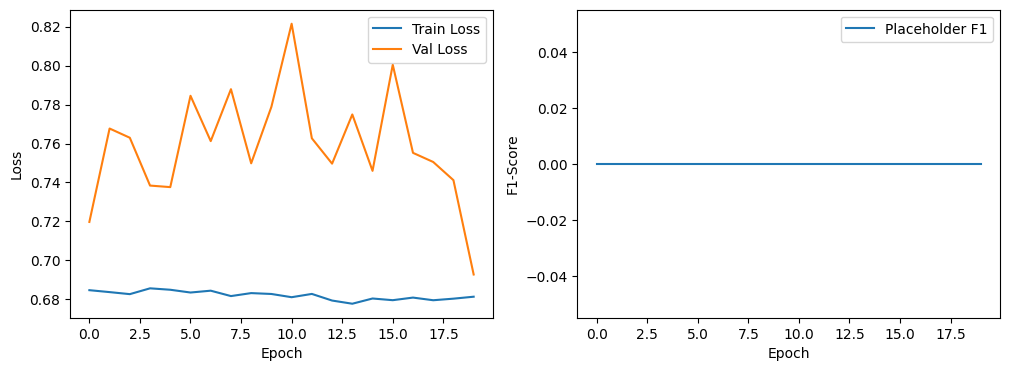

In [27]:
# Train
train_losses, val_losses, _, _ = train_model(model, X_train, y_train, X_val, y_val, num_epochs=20)

# Plot Training Curves (Loss only; F1 from callback print)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(range(len(train_losses)), [0]*len(train_losses), label='Placeholder F1')  # F1 printed during training
plt.xlabel('Epoch')
plt.ylabel('F1-Score')
plt.legend()
plt.show()


In [31]:
# Evaluate on Test Set
eva_result = evaluate_and_visualize(model, X_test, y_test)

82/82 ━━━━━━━━━━━━━━━━━━━━ 20s 230ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 17s 209ms/step

Classification Report:
              precision    recall  f1-score   support

      Normal       0.79      0.48      0.60      1901
     Anomaly       0.31      0.65      0.42       695

    accuracy                           0.53      2596
   macro avg       0.55      0.57      0.51      2596
weighted avg       0.66      0.53      0.55      2596

Overall F1-Score: 0.4242
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step


2026/02/23 10:01:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/23 10:08:59 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpsjd72598/model, flavor: tensorflow). Fall back to return ['tensorflow==2.20.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 684ms/step


2026/02/23 10:09:07 INFO mlflow.models.model: Found the following environment variables used during model inference: [OPENAI_API_KEY]. Please check if you need to set them when deploying the model. To disable this message, set environment variable `MLFLOW_RECORD_ENV_VARS_IN_MODEL_LOGGING` to `false`.


Evaluation complete! Run ID: ce0fddfcded84dc9b429ce16e556cedf
View results at: http://127.0.0.1:5000
🏃 View run ECG_LSTM_Evaluation at: http://127.0.0.1:5000/#/experiments/1/runs/ce0fddfcded84dc9b429ce16e556cedf
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [32]:
# Save model using mlflow
from mlflow.tensorflow import log_model
log_model(model, "ecg_lstm_model_tf")
# Save model using Keras (optional, since MLflow already logged it)
# model.save('ecg_lstm_model_tf.h5')

2026/02/23 10:12:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/23 10:12:32 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2026/02/23 10:14:35 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmp09gg6shf/model, flavor: tensorflow). Fall back to return ['tensorflow==2.20.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 
